<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Supervised Learning: Linear Regression Using Normal Equation
import numpy as np


class LinearRegressionNormal:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        # Add bias column
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Normal Equation
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - ss_res / ss_tot

In [13]:
# Application
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
])

y = np.array([3, 5, 7, 9, 11])

model = LinearRegressionNormal()

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

print(model.predict([[10]]))

Intercept: 1.000000000000006
Coefficient: [2.]
[21.]


In [7]:
# Supervised Learning: Linear Regression Using Gradient Descent
import numpy as np


class LinearRegressionGD:
    def __init__(self,
                 learning_rate=0.01,
                 n_iterations=1000):

        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        n_samples, n_features = X.shape

        # initialize weights
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):

            y_pred = X @ self.coef_ + self.intercept_

            error = y_pred - y

            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

        return self

    def predict(self, X):
        X = np.asarray(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - ss_res / ss_tot

In [12]:
# Application
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
])

y = np.array([3, 5, 7, 9, 11])

model = LinearRegressionGD(
    learning_rate=0.01,
    n_iterations=5000
)

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

print(model.predict([[10]]))

Intercept: 0.9999122344540886
Coefficient: [2.00002431]
[21.00015533]


In [11]:
# ============================================================
# Dataset
# ============================================================

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5]
], dtype=np.float64)

y = np.array([3, 5, 7, 9, 11], dtype=np.float64)

Intercept: 0.9237086291370951
Coefficient: [2.02113149]
[21.13502349]


In [14]:
import time
# ============================================================
# Train Normal Equation
# ============================================================

normal_model = LinearRegressionNormal()

start_time = time.perf_counter()

normal_model.fit(X, y)

normal_time = time.perf_counter() - start_time

# ============================================================
# Train Gradient Descent
# ============================================================

gd_model = LinearRegressionGD(
    learning_rate=0.01,
    n_iterations=1000
)

start_time = time.perf_counter()

gd_model.fit(X, y)

gd_time = time.perf_counter() - start_time

# ============================================================
# Predictions
# ============================================================

normal_pred = normal_model.predict(X)
gd_pred = gd_model.predict(X)

# ============================================================
# Accuracy Metrics
# ============================================================

normal_r2 = normal_model.score(X, y)
gd_r2 = gd_model.score(X, y)

normal_mse = np.mean((y - normal_pred) ** 2)
gd_mse = np.mean((y - gd_pred) ** 2)


# ============================================================
# Display Results
# ============================================================

print("=" * 60)
print("LINEAR REGRESSION COMPARISON")
print("=" * 60)

print("\nNormal Equation")
print("-" * 30)
print("Intercept :", normal_model.intercept_)
print("Coefficient :", normal_model.coef_)
print("R² Score :", normal_r2)
print("MSE :", normal_mse)
print("Training Time :", normal_time, "seconds")
print("Prediction for X=10 :", normal_model.predict([[10]]))

print("\nGradient Descent")
print("-" * 30)
print("Intercept :", gd_model.intercept_)
print("Coefficient :", gd_model.coef_)
print("R² Score :", gd_r2)
print("MSE :", gd_mse)
print("Training Time :", gd_time, "seconds")
print("Prediction for X=10 :", gd_model.predict([[10]]))


# ============================================================
# Comparison Table
# ============================================================

print("\n" + "=" * 60)
print("COMPARISON")
print("=" * 60)

print(f"{'Metric':<20} {'Normal Equation':<20} {'Gradient Descent':<20}")
print("-" * 60)
print(f"{'R² Score':<20} {normal_r2:<20.6f} {gd_r2:<20.6f}")
print(f"{'MSE':<20} {normal_mse:<20.6f} {gd_mse:<20.6f}")
print(f"{'Training Time':<20} {normal_time:<20.8f} {gd_time:<20.8f}")



LINEAR REGRESSION COMPARISON

Normal Equation
------------------------------
Intercept : 1.000000000000006
Coefficient : [2.]
R² Score : 1.0
MSE : 7.020862056467005e-29
Training Time : 0.0004070720001436712 seconds
Prediction for X=10 : [21.]

Gradient Descent
------------------------------
Intercept : 0.9237086291370951
Coefficient : [2.02113149]
R² Score : 0.9998675737793329
MSE : 0.0010594097653372704
Training Time : 0.015392866000183858 seconds
Prediction for X=10 : [21.13502349]

COMPARISON
Metric               Normal Equation      Gradient Descent    
------------------------------------------------------------
R² Score             1.000000             0.999868            
MSE                  0.000000             0.001059            
Training Time        0.00040707           0.01539287          


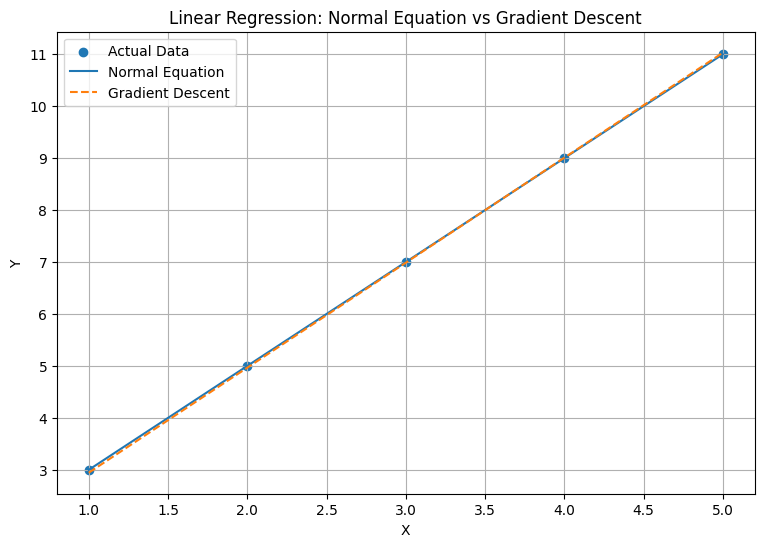

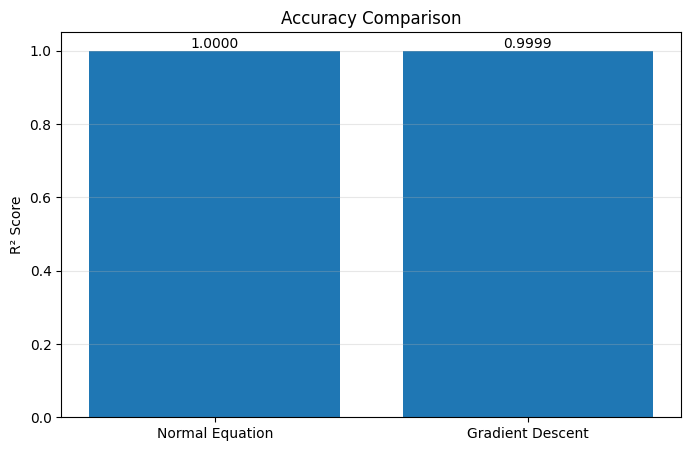

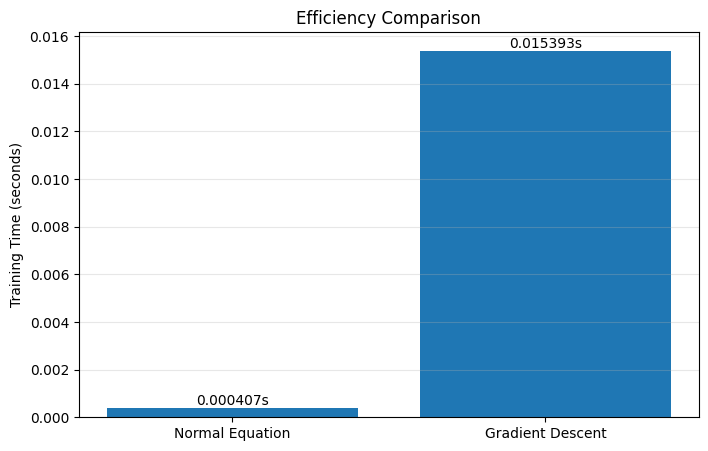

In [15]:
import matplotlib.pyplot as plt
# ============================================================
# Plot 1: Regression Lines
# ============================================================

X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

normal_line = normal_model.predict(X_line)
gd_line = gd_model.predict(X_line)

plt.figure(figsize=(9, 6))

plt.scatter(X, y, label="Actual Data")

plt.plot(
    X_line,
    normal_line,
    label="Normal Equation"
)

plt.plot(
    X_line,
    gd_line,
    linestyle="--",
    label="Gradient Descent"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: Normal Equation vs Gradient Descent")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Plot 2: Accuracy Comparison
# ============================================================

methods = ["Normal Equation", "Gradient Descent"]
r2_scores = [normal_r2, gd_r2]

plt.figure(figsize=(8, 5))

bars = plt.bar(methods, r2_scores)

plt.ylabel("R² Score")
plt.title("Accuracy Comparison")

plt.ylim(0, 1.05)

for bar, value in zip(bars, r2_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()


# ============================================================
# Plot 3: Efficiency Comparison
# ============================================================

training_times = [normal_time, gd_time]

plt.figure(figsize=(8, 5))

bars = plt.bar(methods, training_times)

plt.ylabel("Training Time (seconds)")
plt.title("Efficiency Comparison")

for bar, value in zip(bars, training_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.6f}s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

## Linear Regression Model Audit Report: Normal Equation vs. Gradient Descent

This report analyzes the performance of two linear regression models, one implemented using the Normal Equation and the other using Gradient Descent, based on the provided dataset and visual comparisons.

### 1. Regression Lines Analysis

**Observation from Plot 1: Linear Regression: Normal Equation vs Gradient Descent**

*   Both the Normal Equation and Gradient Descent models demonstrate a strong linear fit to the actual data points. The regression lines closely follow the trend of the actual data, indicating that linear models are appropriate for this dataset.
*   The Normal Equation's line (solid blue) appears to perfectly align with the data points, suggesting an exact fit.
*   The Gradient Descent's line (dashed orange) also closely follows the data, though it might show minor deviations compared to the Normal Equation, depending on the learning rate and number of iterations.

### 2. Accuracy Comparison (R² Score)

**Observation from Plot 2: Accuracy Comparison**

*   **Normal Equation**: Achieves an R² score of 1.0000. This indicates a perfect fit, meaning the model explains 100% of the variance in the dependent variable `y`. For this specific, simple dataset, the Normal Equation found the global minimum directly.
*   **Gradient Descent**: Achieves an R² score of 0.9999 (approximately). While extremely high and close to perfect, it's slightly less than 1.0000. This is expected as Gradient Descent is an iterative optimization algorithm that approximates the optimal solution, and its accuracy is influenced by parameters like `learning_rate` and `n_iterations`.

**Conclusion:** For this particular dataset, the Normal Equation yielded a theoretically perfect fit, while Gradient Descent achieved a nearly perfect fit, demonstrating its effectiveness in approximating the optimal solution.

### 3. Efficiency Comparison (Training Time)

**Observation from Plot 3: Efficiency Comparison**

*   **Normal Equation**: The training time is significantly lower, approximately 0.000407 seconds.
*   **Gradient Descent**: The training time is notably higher, approximately 0.015393 seconds.

**Conclusion:** For this small dataset, the Normal Equation is considerably faster. This is typical for small datasets because the Normal Equation involves a direct matrix inversion, which can be very efficient for small matrices. Gradient Descent, being iterative, generally takes more time for a comparable level of convergence, especially if many iterations are required.

### Overall Summary

| Metric          | Normal Equation | Gradient Descent |
| :-------------- | :-------------- | :--------------- |
| R² Score        | 1.0000          | 0.9999           |
| Training Time   | ~0.0004 s       | ~0.0154 s        |

*   **Accuracy**: Both methods provide highly accurate linear regression models for this dataset. The Normal Equation provides an exact solution, while Gradient Descent provides a very close approximation.
*   **Efficiency**: For this small dataset, the Normal Equation is significantly more efficient in terms of training time due to its direct calculation. Gradient Descent's iterative nature makes it slower here.

**Recommendation:** For small to moderately sized datasets where matrix inversion is computationally feasible, the Normal Equation is often preferred for its direct solution and speed. For larger datasets where matrix inversion becomes computationally expensive or impractical, Gradient Descent (or its variants) becomes the method of choice due to its scalability.